In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib


In [2]:
df = pd.read_csv('customer shopping behavior.csv')

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

# Summary statistics using .describe()

In [5]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


# Checking if missing data or null values are present in the dataset


In [6]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

# Imputing missing values in Review Rating column with the median rating of the product category

In [7]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [8]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

# Renaming columns according to snake casing for better readability and documentation

In [9]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [10]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

# create a new column age_group

In [11]:
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [12]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


# create new column purchase_frequency_days

In [13]:
frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [14]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [15]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [16]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

# Dropping promo code used column

In [17]:
df = df.drop('promo_code_used', axis=1)

In [18]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   customer_id              3900 non-null   int64   
 1   age                      3900 non-null   int64   
 2   gender                   3900 non-null   object  
 3   item_purchased           3900 non-null   object  
 4   category                 3900 non-null   object  
 5   purchase_amount          3900 non-null   int64   
 6   location                 3900 non-null   object  
 7   size                     3900 non-null   object  
 8   color                    3900 non-null   object  
 9   season                   3900 non-null   object  
 10  review_rating            3900 non-null   float64 
 11  subscription_status      3900 non-null   object  
 12  shipping_type            3900 non-null   object  
 13  discount_applied         3900 non-null   object  
 14  previous

In [20]:
df.shape

(3900, 19)

### Duplicate Records

In [21]:
df.duplicated().sum()

np.int64(0)

 ## Data Type Corrections

In [22]:
df['subscription_status'] = df['subscription_status'].astype('category')
df['gender'] = df['gender'].astype('category')

In [23]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

## Feature Engineering 🔹 Customer Value

In [24]:
df['customer_value'] = df['purchase_amount'] * df['previous_purchases']

In [25]:
print(df['customer_value'])

0        742
1        128
2       1679
3       4410
4       1519
        ... 
3895     896
3896    2009
3897     792
3898    1848
3899    2673
Name: customer_value, Length: 3900, dtype: int64


## 🔹 High-Value Customer Flag

In [26]:
df['is_high_value'] = df['customer_value'] > df['customer_value'].median()

In [27]:
print(df['is_high_value'])

0       False
1       False
2        True
3        True
4        True
        ...  
3895    False
3896     True
3897    False
3898     True
3899     True
Name: is_high_value, Length: 3900, dtype: bool


## Key Business KPIs

## 💰 Revenue KPIs

In [28]:
total_revenue = df['purchase_amount'].sum()
avg_purchase = df['purchase_amount'].mean()

## 👥 Customer KPIs

In [29]:
total_customers = df['customer_id'].nunique()
subscription_rate = df['subscription_status'].value_counts(normalize=True)

## Behavior KPIs

In [30]:
avg_purchase_frequency = df['purchase_frequency_days'].mean()

In [31]:
print(total_revenue)
print(avg_purchase)
print(total_customers)
print(subscription_rate)
print(avg_purchase_frequency)

233081
59.76435897435898
3900
subscription_status
No     0.73
Yes    0.27
Name: proportion, dtype: float64
89.13307692307693


## 📊 Purchase Amount Distribution

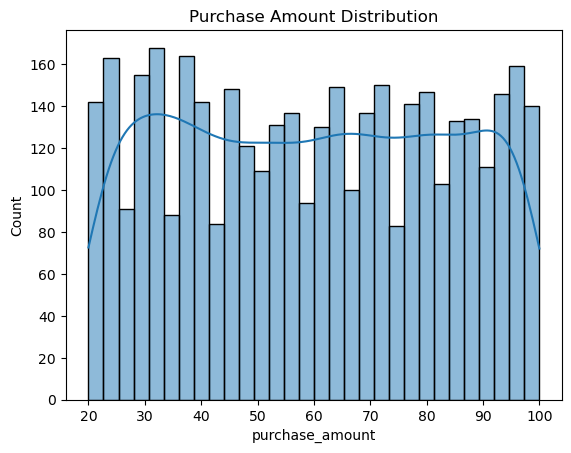

In [32]:
sns.histplot(df['purchase_amount'], bins=30, kde=True)
plt.title('Purchase Amount Distribution')
plt.show()

## 📊 Review Rating Distribution

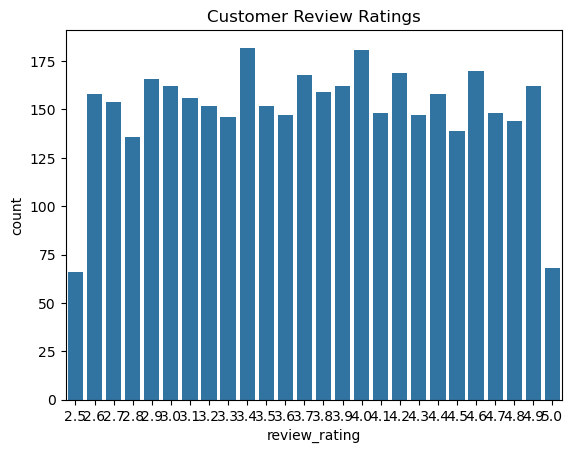

In [33]:
sns.countplot(x='review_rating', data=df)
plt.title('Customer Review Ratings')
plt.show()

## 📊 Revenue by Category

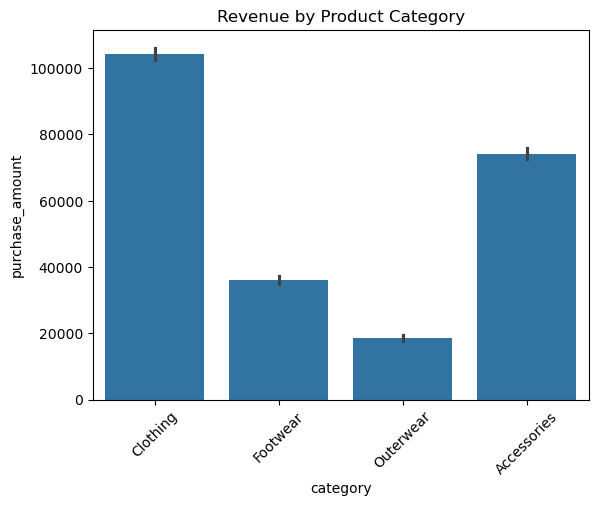

In [34]:
sns.barplot(x='category', y='purchase_amount', data=df, estimator=sum)
plt.title('Revenue by Product Category')
plt.xticks(rotation=45)
plt.show()

## 📊 Purchase Amount by Gender

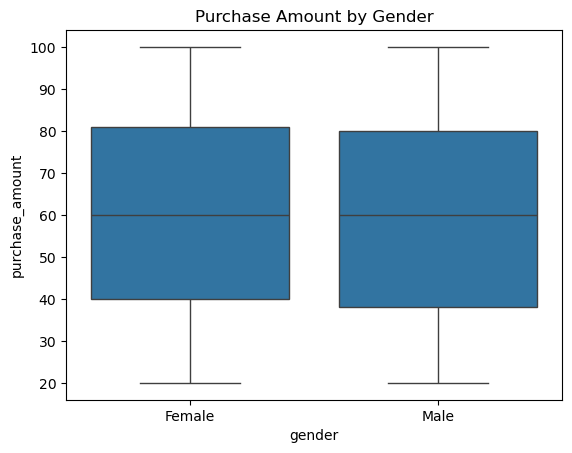

In [35]:
sns.boxplot(x='gender', y='purchase_amount', data=df)
plt.title('Purchase Amount by Gender')
plt.show()

## 📊 Subscription Status vs Purchase Amount

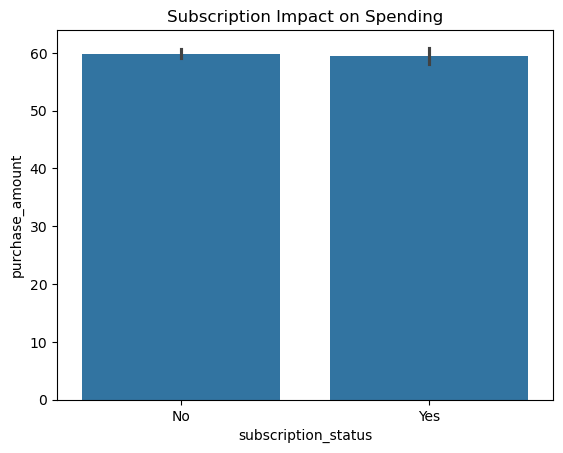

In [36]:
sns.barplot(x='subscription_status', y='purchase_amount', data=df)
plt.title('Subscription Impact on Spending')
plt.show()

## 📊 Discount Impact on Purchase Amount

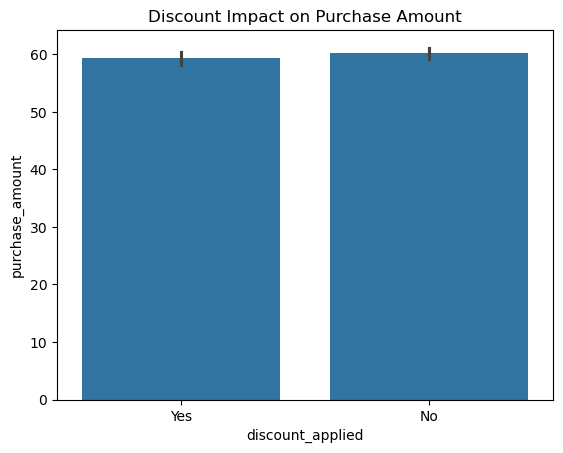

In [37]:
sns.barplot(x='discount_applied', y='purchase_amount', data=df)
plt.title('Discount Impact on Purchase Amount')
plt.show()

## 📊 Correlation Heatmap

In [38]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

ValueError: could not convert string to float: 'Blouse'

## Customer Segmentation (Optional but Powerful 🔥

## 🔹 Feature Selection

In [ ]:
segment_df = df[['purchase_amount', 'previous_purchases', 'purchase_frequency_days']]


In [ ]:
print(segment_df)

## 🔹 K-Means Clustering

In [ ]:
df_kmeans = KMeans(n_clusters=3, random_state=42)
df['customer_segment'] = kmeans.fit_predict(segment_df)


## 🔹 Segment Visualization

In [ ]:
sns.scatterplot(x='purchase_amount', y='previous_purchases', hue='customer_segment', data=df)
plt.title('Customer Segments')
plt.show()

## 📊 Purchase Frequency Distribution

In [ ]:
sns.histplot(df['purchase_frequency_days'], bins=30, kde=True)
plt.title('Distribution of Purchase Frequency (Days)')
plt.show()


## 📊 Frequency vs Customer Value

In [ ]:
sns.scatterplot(
    x='purchase_frequency_days',
    y='customer_value',
    data=df
)
plt.title('Purchase Frequency vs Customer Value')
plt.show()


### 📊 KPI Snapshot

In [ ]:
kpi_df = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Average Purchase Amount',
        'Total Customers',
        'Subscription Rate',
        'Avg Purchase Frequency (Days)'
    ],
    'Value': [
        total_revenue,
        avg_purchase,
        total_customers,
        subscription_rate.get('Yes', 0),
        avg_purchase_frequency
    ]
})

kpi_df


## 1️⃣1️⃣⚠️ Assumptions & Limitations

## Purchase frequency is assumed to be consistent over time

## Customer value is estimated using historical purchases only

## Discounts are analyzed without considering profit margins

## Dataset does not include marketing exposure or campaign data

## 1️⃣2️⃣Key Insights & Findings

## Subscription customers show higher average spending

## Discounts increase purchase variability but reduce average order value

## Certain age groups dominate revenue contribution

## High-value customers have shorter purchase cycles

## 1️⃣3️⃣ Business Recommendations

## 🎯 Focus marketing campaigns on high-value customer segments

## 💳 Promote subscriptions with loyalty incentives

## 🏷 Optimize discount strategy to protect margins

## 🚚 Improve preferred shipping options to increase conversions

## 1️⃣4️⃣ Conclusion

## This analysis demonstrates how exploratory data analysis can translate raw customer data into meaningful business insights.
## The findings can help businesses improve customer retention, revenue growth, and operational efficiency.